# Importing the Libraries

In [1]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader,Dataset
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import albumentations as A
from albumentations.pytorch import ToTensorV2
import copy
from tqdm.notebook import tqdm # Import tqdm for progress bars

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tarundalal/top-15-anime-main-charcters")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'top-15-anime-main-charcters' dataset.
Path to dataset files: /kaggle/input/top-15-anime-main-charcters


In [3]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p = 0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=24, max_width=24, p=0.3),
    A.ToGray(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_9272/3776627445.py:6: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=24, max_width=24, p=0.3),


In [4]:
class AlbumentationsSubset(Dataset):
    def __init__(self,subset,transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        # Retrive the PIL image and label from the original subset
        img, label = self.subset[index]
        # Convert PIL Image to a NumPy array for Albumenations
        img_np = np.array(img)

        if self.transform:
            argumented = self.transform(image=img_np)
            img_tensor = argumented['image']

        # Convert NumPy array back to PIL Image

        return img_tensor, label

    def __len__(self):
        return len(self.subset)


In [5]:
from sklearn import base
base_dataset = datasets.ImageFolder(root=os.path.join(path, 'anime_characters'))

class_names = base_dataset.classes

In [6]:
print(base_dataset)
print(class_names)

Dataset ImageFolder
    Number of datapoints: 1432
    Root location: /kaggle/input/top-15-anime-main-charcters/anime_characters
['Elric Edward', 'Eren Yeager', 'Goku', 'Gon', 'Ichigo', 'Killua', 'Lelouch Lamperouge', 'Light Yagami', 'Luffy', 'Naruto', 'Natsu Dragneel', 'Sakata Gintoki', 'Sasuke', 'Vegeta', 'Zoro']


In [7]:
train_indices, test_indices = train_test_split(list(range(len(base_dataset))), test_size=0.2, random_state=42)

train_data_wrapped = AlbumentationsSubset(torch.utils.data.Subset(base_dataset, train_indices), transform=train_transform)

test_data_wrapped = AlbumentationsSubset(torch.utils.data.Subset(base_dataset, test_indices), transform=test_transform)

In [8]:
print("First 5 records from test_data_wrapped:")
for i in range(5):
    image_tensor, label = test_data_wrapped[i]
    print(f"Record {i+1}: Image Shape = {image_tensor.shape}, Label = {label}")

First 5 records from test_data_wrapped:
Record 1: Image Shape = torch.Size([3, 224, 224]), Label = 1
Record 2: Image Shape = torch.Size([3, 224, 224]), Label = 12
Record 3: Image Shape = torch.Size([3, 224, 224]), Label = 4
Record 4: Image Shape = torch.Size([3, 224, 224]), Label = 3
Record 5: Image Shape = torch.Size([3, 224, 224]), Label = 11


In [9]:
train_loader = DataLoader(train_data_wrapped, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data_wrapped, batch_size=32, shuffle=False)

In [10]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
feature_extractor = nn.Sequential(*list(model.children())[:-1]) # chopping off final layer
print(feature_extractor)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [12]:
X_train_list,y_train_list = [],[]
EPOCHS = 20

checkpoint_dir = 'feature_extraction_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Try to load existing checkpoint
start_epoch = 0
checkpoint_file_X = os.path.join(checkpoint_dir, 'X_train_checkpoint.joblib')
checkpoint_file_y = os.path.join(checkpoint_dir, 'y_train_checkpoint.joblib')
checkpoint_file_epoch = os.path.join(checkpoint_dir, 'current_epoch.joblib')

if os.path.exists(checkpoint_file_X) and os.path.exists(checkpoint_file_y) and os.path.exists(checkpoint_file_epoch):
    X_train_list = joblib.load(checkpoint_file_X)
    y_train_list = joblib.load(checkpoint_file_y)
    start_epoch = joblib.load(checkpoint_file_epoch) + 1 # Start from the next epoch
    print(f"Resuming training from Epoch {start_epoch}.")

with torch.no_grad():
    for i in range(start_epoch, EPOCHS):
        # Wrap train_loader with tqdm for progress bar and epoch counter
        current_epoch_X_list = [] # Temporarily store features for current epoch
        current_epoch_y_list = [] # Temporarily store labels for current epoch
        for images, labels in tqdm(train_loader, desc=f"Epoch {i+1}/{EPOCHS}"):
            features = feature_extractor(images)
            features = features.squeeze()
            if len(features.shape) == 1:
                features = features.unsqueeze(0)


            current_epoch_X_list.append(features.numpy())
            current_epoch_y_list.append(labels.numpy())

        # Append current epoch's data to the overall list
        X_train_list.extend(current_epoch_X_list)
        y_train_list.extend(current_epoch_y_list)

        # Save checkpoint after each epoch
        joblib.dump(X_train_list, checkpoint_file_X)
        joblib.dump(y_train_list, checkpoint_file_y)
        joblib.dump(i, checkpoint_file_epoch)
        print(f"Checkpoint saved after Epoch {i+1}.")

X_train = np.vstack(X_train_list)
y_train = np.concatenate(y_train_list)

print(X_train.shape)
print(y_train.shape)

Resuming training from Epoch 16.


Epoch 17/20:   0%|          | 0/36 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Checkpoint saved after Epoch 17.


Epoch 18/20:   0%|          | 0/36 [00:00<?, ?it/s]

Checkpoint saved after Epoch 18.


Epoch 19/20:   0%|          | 0/36 [00:00<?, ?it/s]

Checkpoint saved after Epoch 19.


Epoch 20/20:   0%|          | 0/36 [00:00<?, ?it/s]

Checkpoint saved after Epoch 20.
(22900, 512)
(22900,)


In [13]:
X_test_list,y_test_list = [],[]

with torch.no_grad():
    for images,labels in tqdm(test_loader, desc="Extracting Test Features"):
        features = feature_extractor(images)
        features = features.squeeze()
        if features.ndim==1:
            features = features.unsqueeze(0)
        X_test_list.append(features.numpy())
        y_test_list.append(labels.numpy())

X_test = np.vstack(X_test_list)
y_test = np.concatenate(y_test_list)

print(X_test.shape)
print(y_test.shape)

Extracting Test Features:   0%|          | 0/9 [00:00<?, ?it/s]

(287, 512)
(287,)


# PCA

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(X_train_pca.shape)
print(X_test_pca.shape)

(22900, 264)
(287, 264)


# Train with XGBoost

In [15]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
    tree_method = 'hist'  # speed up execution significantly
    )


In [18]:
xgb_model.fit(X_train_pca, y_train)

TypeError: got an unexpected keyword argument 'class_names'

In [20]:
y_pred = xgb_model.predict(X_test_pca)

print(classification_report(y_test, y_pred, target_names=class_names))

                    precision    recall  f1-score   support

      Elric Edward       0.75      0.67      0.71        18
       Eren Yeager       0.60      0.69      0.64        13
              Goku       0.52      0.52      0.52        25
               Gon       0.80      0.47      0.59        17
            Ichigo       0.68      0.79      0.73        19
            Killua       0.56      0.64      0.60        14
Lelouch Lamperouge       0.90      0.83      0.86        23
      Light Yagami       0.53      0.67      0.59        15
             Luffy       0.70      0.88      0.78        32
            Naruto       0.78      0.58      0.67        12
    Natsu Dragneel       0.60      0.67      0.63        18
    Sakata Gintoki       0.74      0.70      0.72        20
            Sasuke       0.69      0.41      0.51        22
            Vegeta       0.36      0.53      0.43        15
              Zoro       0.90      0.75      0.82        24

          accuracy                    

## Plotting the Confusion Matrix

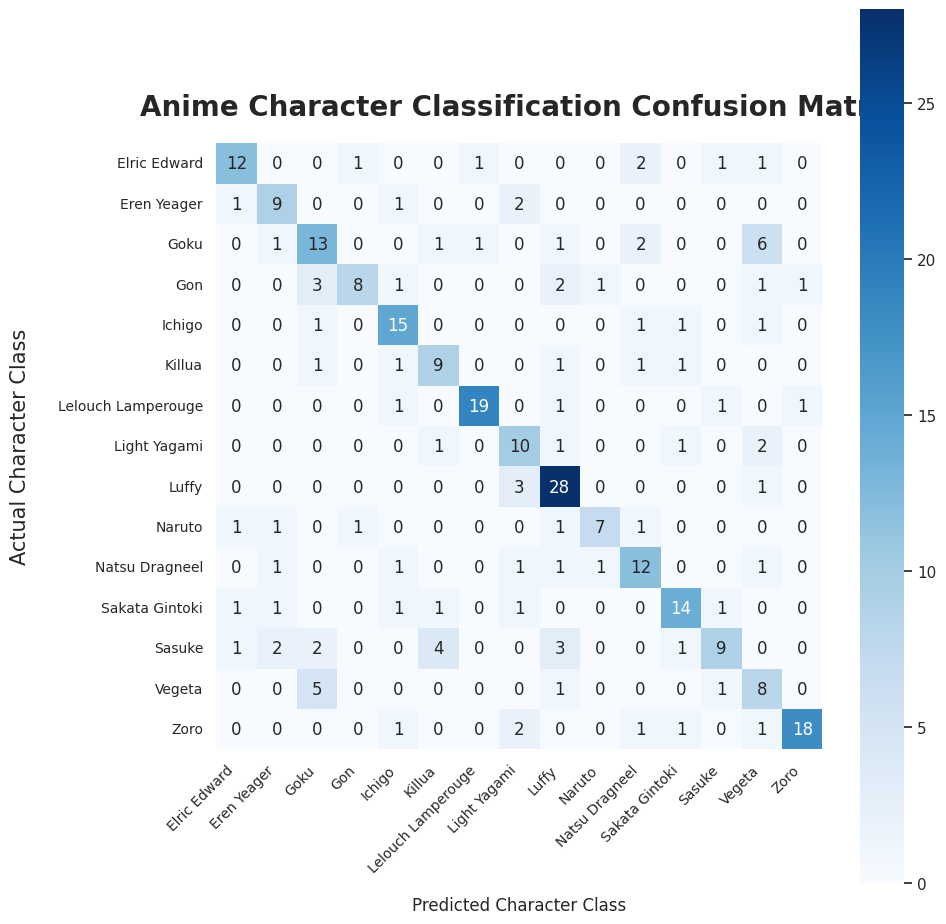

In [21]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,10))
sns.set_theme(style="whitegrid")

sns.heatmap(
    cm,
    annot=True,                        # put number inside boxa
    cmap="Blues",                   # high contrast color
    fmt="d",                       # format value as integer
    xticklabels=class_names,
    yticklabels=class_names,
    square = True
)


plt.title("Anime Character Classification Confusion Matrix", fontsize=20,fontweight = "bold", pad = 20)
plt.ylabel("Actual Character Class", fontsize=15, labelpad = 20)
plt.xlabel("Predicted Character Class",fontsize = 12, labelpad = 15)
plt.xticks(rotation = 45, ha = 'right', fontsize = 10)
plt.yticks(rotation = 0,fontsize = 10)
plt.tight_layout()
plt.show()

In [24]:
os.makedirs("models",exist_ok=True)

## Saving the Parameters

In [25]:
production_pipeline={
    'scaler':scaler,
    'pca':pca,
    'model':xgb_model,
    "class_names":class_names
}

pipeline_path = os.path.join("models","anime_classifier_pipeline.pkl")
joblib.dump(production_pipeline, pipeline_path)



['models/anime_classifier_pipeline.pkl']

In [26]:
from google.colab import files

# Trigger the download for the main pipeline package
files.download('models/anime_classifier_pipeline.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>